# Lead Scoring — RF & HGB Hyperparameter Search
#
# **Primary KPI**: `AUC × 100 + decile_gap_pp`  (higher = better)
#
# | Metric | What it measures |
# |---|---|
# | AUC | rank-ordering quality (0-1 → 0-100 after scaling) |
# | decile_gap_pp | D10 SE − D1 SE (percentage points, 0-100) |
# | composite | AUC×100 + gap_pp — single number to maximise |
#
# Notebook sections:
# 1. Config & Imports
# 2. Data Load & Feature Selection
# 3. Prep & Train/Test Split
# 4. Evaluation Utilities
# 5. RF Hyperparameter Sweep
# 6. HGB Hyperparameter Sweep
# 7. Combined Leaderboard
# 8. Best-Model Deep Dive (decile curve, ROC, feature importance)
# 9. Correlation & Collinearity Analysis
# 10. Comparison with Existing Scores

## 1 · Config & Imports

In [1]:
import re
import pandas as pd
import numpy as np
import time
import warnings
from tqdm.auto import tqdm
warnings.filterwarnings("ignore")

from itertools import product as iterproduct
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    HistGradientBoostingRegressor, HistGradientBoostingClassifier,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.tree import export_text

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── plot theme ──
plt.rcParams.update({
    "figure.facecolor": "#0a0e17",
    "axes.facecolor":   "#111827",
    "axes.edgecolor":   "#1e293b",
    "axes.labelcolor":  "#9ca3af",
    "xtick.color":      "#6b7280",
    "ytick.color":      "#6b7280",
    "text.color":       "#e2e8f0",
    "grid.color":       "#1e293b",
    "font.family":      "monospace",
    "font.size":        10,
})
AMBER  = "#f0b429"
BLUE   = "#60a5fa"
GREEN  = "#10b981"
RED    = "#ef4444"
PURPLE = "#a78bfa"
CYAN   = "#22d3ee"
PINK   = "#f472b6"
GRAY   = "#4a5568"

# ── sweep config ──
N_RANDOM_SAMPLES = 120        # random combos per model type
TEST_SIZE        = 0.30
RANDOM_STATE     = 42
FILL_VALUE       = -999


/Users/Rohanchoudhary/Desktop/projs/genie_stocks/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2 · Data Load & Feature Selection

In [2]:
df = pd.read_hdf("../reports/test_scored.h5", "df")
print(f"Shape before ops merge: {df.shape}")

# ── MERGE PARTNER OPS (TRAIN window — leak-free) ──
df_ops_train = pd.read_csv("../reports/partner_ops_train_vector.csv")
print(f"Ops train: {df_ops_train.shape}")

# Infer temporal windows from CSV columns (no data_lib import needed)
TEMPORAL_WINDOWS = sorted([
    int(c.replace("se_", "").replace("d", ""))
    for c in df_ops_train.columns
    if re.match(r"^se_\d+d$", c) and "delta" not in c
])
print(f"Temporal windows detected: {TEMPORAL_WINDOWS}")

smallest_wd = min(TEMPORAL_WINDOWS)
rf_ops_cols = ["partner_id"]
for wd in TEMPORAL_WINDOWS:
    rf_ops_cols += [f"se_{wd}d", f"decline_rate_{wd}d", f"median_response_min_{wd}d"]
    if wd != smallest_wd:
        rf_ops_cols += [
            f"se_delta_{smallest_wd}_{wd}",
            f"decline_rate_delta_{smallest_wd}_{wd}",
            f"response_delta_{smallest_wd}_{wd}",
        ]
rf_ops_cols += [
    "queue_velocity", "plan_created_rate", "active_tickets",
    "nmbr_active_leads", "expected_daily_slots", "has_shock",
]
rf_ops_cols = [c for c in rf_ops_cols if c in df_ops_train.columns]
print(df.columns)
# Merge
df["partner_id"] = df["partner_id"].astype(str)
df_ops_train["partner_id"] = df_ops_train["partner_id"].astype(str)
df = df.merge(df_ops_train[rf_ops_cols], on="partner_id", how="left", suffixes=("", "_ops"))
df = df.loc[:, ~df.columns.str.endswith("_ops")]
print(f"Shape after ops merge: {df.shape}")
print(f"Ops columns merged: {len(rf_ops_cols) - 1}")

TARGET = "installed_decision"

# ── LEAK-FREE FEATURES ──
# Spatial features: from TRAIN window (safe).
# Ops features: from TRAIN window ops vector (safe — not test window).

FEATURES = [
    # ── SPATIAL — Gaussian KDE from training sources ──
    "predicted_field_hex",
    "predicted_field_hex_all_wmean",
    "predicted_field_hex_all_kswmean",
    "predicted_field_hex_all_min",
    "predicted_field_hex_all_max",
    "predicted_field_hex_all_std",
    "n_overlapping_hexes_field",
    "total_sources_all_hexes",
    "contested_field",

    # ── TEMPORAL FIELD ──
    "predicted_field_hex_30d",
    "predicted_field_hex_60d",
    "predicted_field_hex_365d",
    "field_momentum",

    # ── HEX CONSENSUS — shrunk SE from training ──
    "parent_se",
    "parent_total",
    "parent_color_numeric",
    "n_covering_partners",
    "parent_overlap",
    "install_velocity",

    # ── TEMPORAL HEX SE ──
    "weighted_se_30d_shrunk",
    "weighted_se_60d_shrunk",
    "weighted_se_365d_shrunk",
    "se_momentum",

    # ── HOP — neighbor SE aggregates ──
    "hop1_se_wmean", "hop2_se_wmean", "hop3_se_wmean",
    "hop1_se_std",   "hop2_se_std",   "hop3_se_std",
    "hop1_count",    "hop2_count",    "hop3_count",
    "se_gradient_1to3", "se_confirmed", "isolation_ratio",

    # ── TEMPORAL HOP SE ──
    "hop1_se_30d_wmean",  "hop2_se_30d_wmean",  "hop3_se_30d_wmean",
    "hop1_se_60d_wmean",  "hop2_se_60d_wmean",  "hop3_se_60d_wmean",
    "hop1_se_365d_wmean", "hop2_se_365d_wmean", "hop3_se_365d_wmean",
    "se_gradient_1to3_30d",  "se_gradient_1to3_60d",  "se_gradient_1to3_365d",
    "se_confirmed_30d",      "se_confirmed_60d",      "se_confirmed_365d",

    # ── CONTESTED — overlap zone ──
    "contested_area_km2",
    "contested_radius_m",
    "contested_se",
    "contested_se_30d", "contested_se_60d", "contested_se_365d",
    "n_overlapping_partners",

    # ── BOUNDARY — cluster geometry ──
    "dist_to_boundary_edge_point_hex",
    "dist_to_cluster_center_point_hex",
    "depth_score_point_hex",
    "mean_dist_to_edge_m", "mean_dist_to_center_m",
    "total_area_boundaries", "nmbr_overlap_clusters",
    "nearest_boundary_dist_m", "nmbr_boundaries_within_100m",
    "worst_depth_score", "any_near_edge", "is_solo_cluster",

    # ── GEOMETRIC PATTERN ──
    "local_anisotropy", "local_density", "hull_area",
    "linearity_score", "spread_m",
    "dense_score", "gully_score", "sparse_score",

    # ── TEMPORAL GEOMETRY ──
    "local_density_30d",  "local_density_60d",  "local_density_365d",
    "dense_score_30d",    "dense_score_60d",    "dense_score_365d",
    "sparse_score_30d",   "sparse_score_60d",   "sparse_score_365d",
    "spread_m_30d",       "spread_m_60d",       "spread_m_365d",

    # ── LEAD-LEVEL ──
    "hard_density",
    "density_regime",
    "min_dist",
]

# ── OPS FEATURES (TRAIN window — leak-free) ──
_ops_feature_cols = [c for c in rf_ops_cols if c != "partner_id"]
FEATURES += _ops_feature_cols

available = [f for f in FEATURES if f in df.columns]
missing   = [f for f in FEATURES if f not in df.columns]
print(f"\nUsing {len(available)}/{len(FEATURES)} features, missing {len(missing)}:")
for m in missing:
    print(f"  - {m}")

ops_available = [f for f in _ops_feature_cols if f in df.columns]
print(f"\nOps features available: {len(ops_available)}/{len(_ops_feature_cols)}")
for f in ops_available:
    print(f"  + {f}")


Shape before ops merge: (18082, 204)
Ops train: (1475, 43)
Temporal windows detected: [30, 60, 365]
Index(['mobile', 'latitude', 'longitude', 'nmbr_partners_x', 'decision_time',
       'installed_decision', 'installed_time', 'hard_density',
       'density_regime', 'local_anisotropy',
       ...
       'norm_hop3_se_365d', 'norm_gradient_365d', 'norm_confirmed_365d',
       'norm_density_365d', 'norm_evidence_365d', 'norm_field_365d',
       'spatial_shrunk_30d', 'spatial_shrunk_60d', 'spatial_shrunk_365d',
       'boundary_dist_bucket'],
      dtype='str', length=204)
Shape after ops merge: (18082, 223)
Ops columns merged: 19

Using 111/111 features, missing 0:

Ops features available: 19/19
  + se_30d
  + decline_rate_30d
  + median_response_min_30d
  + se_60d
  + decline_rate_60d
  + median_response_min_60d
  + se_delta_30_60
  + decline_rate_delta_30_60
  + response_delta_30_60
  + se_365d
  + decline_rate_365d
  + median_response_min_365d
  + se_delta_30_365
  + decline_rate_delta

## 3 · Prep & Train/Test Split

In [3]:
X = df[available].copy()
y = df[TARGET].copy()

mask = y.notna()
X, y = X[mask], y[mask]
X = X.fillna(FILL_VALUE)

print(f"Samples: {len(X)},  Features: {X.shape[1]},  Install rate: {y.mean():.4f}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y.astype(int),
)
print(f"Train: {len(X_train)}  Test: {len(X_test)}")
print(f"Train SE: {y_train.mean():.4f}  Test SE: {y_test.mean():.4f}")

Samples: 18082,  Features: 111,  Install rate: 0.5794
Train: 12657  Test: 5425
Train SE: 0.5794  Test SE: 0.5794


## 4 · Evaluation Utilities

**Composite KPI** = `AUC × 100 + gap_pp`

- AUC ∈ [0.5, 1.0] → scaled to [50, 100]
- gap_pp = (D10_SE − D1_SE) × 100  → typically 0–60
- So composite ≈ 50–160 range; higher is better.

In [ ]:
def eval_model(model, X_tr, y_tr, X_te, y_te):
    """Evaluate a fitted model. Returns dict with all metrics."""
    p_train = model.predict(X_tr)
    p_test  = model.predict(X_te)

    # AUC (use predict output as score — works for both regressor & classifier)
    auc_train = roc_auc_score(y_tr, p_train)
    auc_test  = roc_auc_score(y_te, p_test)

    # Decile table on test
    edf = pd.DataFrame({"y": y_te.values, "p": p_test})
    edf["decile"] = pd.qcut(edf["p"], q=10, labels=False, duplicates="drop") + 1
    tbl = edf.groupby("decile").agg(n=("y", "count"), inst=("y", "sum"))
    tbl["se"] = tbl["inst"] / tbl["n"]

    d1_se  = tbl["se"].iloc[0]
    d10_se = tbl["se"].iloc[-1]
    gap_pp = (d10_se - d1_se) * 100          # percentage points
    mono   = bool((tbl["se"].diff().dropna() >= 0).all())

    # Composite KPI
    composite = auc_test * 100 + gap_pp

    return {
        "auc_train":  round(auc_train, 4),
        "auc_test":   round(auc_test, 4),
        "gap_pp":     round(gap_pp, 2),
        "d1_se":      round(d1_se, 4),
        "d10_se":     round(d10_se, 4),
        "mono":       mono,
        "composite":  round(composite, 2),
        "decile_tbl": tbl,
    }


def print_leaderboard(results_df, title, top_n=15):
    """Print a compact leaderboard sorted by composite KPI."""
    df_s = results_df.sort_values("composite", ascending=False).head(top_n).reset_index(drop=True)
    print(f"\n{'='*90}")
    print(f"  {title}  (top {top_n} by composite = AUC×100 + gap_pp)")
    print(f"{'='*90}")
    cols = [c for c in df_s.columns if c != "decile_tbl"]
    print(df_s[cols].to_string(index=True))
    return df_s

## 5 · Random Forest — Hyperparameter Sweep

In [5]:
rf_grid = {
    "n_estimators":    [200, 300, 500],
    "max_depth":       [6, 8, 12, 16, None],
    "min_samples_leaf": [20, 50, 100, 200],
    "max_features":    ["sqrt", 0.3, 0.5],
}

np.random.seed(RANDOM_STATE)
all_rf = list(iterproduct(*rf_grid.values()))
sample_idx = np.random.choice(len(all_rf), size=min(N_RANDOM_SAMPLES, len(all_rf)), replace=False)
sampled_rf = [all_rf[i] for i in sample_idx]

print(f"RF grid: {len(all_rf)} total combos → sampling {len(sampled_rf)}")

rf_results = []
best_composite = -np.inf

for n_est, md, msl, mf in tqdm(sampled_rf, desc="RF sweep"):
    model = RandomForestRegressor(
        n_estimators=n_est, max_depth=md, min_samples_leaf=msl,
        max_features=mf, random_state=RANDOM_STATE, n_jobs=-1,
    )
    model.fit(X_train, y_train)
    ev = eval_model(model, X_train, y_train, X_test, y_test)

    rf_results.append({
        "model": "RF",
        "n_estimators": n_est, "max_depth": md,
        "min_samples_leaf": msl, "max_features": mf,
        "auc_train":  ev["auc_train"],
        "auc_test":   ev["auc_test"],
        "gap_pp":     ev["gap_pp"],
        "mono":       ev["mono"],
        "composite":  ev["composite"],
    })
    if ev["composite"] > best_composite:
        best_composite = ev["composite"]
        print(ev["gap_pp"], ev["auc_test"])
        print(best_composite)

print(f"\nRF sweep done — {len(sampled_rf)} experiments, best composite: {best_composite:.2f}")
rf_df = pd.DataFrame(rf_results)
print_leaderboard(rf_df, "RANDOM FOREST LEADERBOARD")


RF grid: 180 total combos → sampling 120


RF sweep:   1%|          | 1/120 [00:01<03:54,  1.97s/it]

59.12 0.6881
127.93


RF sweep:   2%|▏         | 2/120 [00:02<02:29,  1.27s/it]

60.41 0.6891
129.31


...

RF sweep:  90%|█████████ | 108/120 [05:34<00:45,  3.76s/it]

65.93 0.7025
136.18


RF sweep: 100%|██████████| 120/120 [06:07<00:00,  3.06s/it]


RF sweep done — 120 experiments, best composite: 136.18

  RANDOM FOREST LEADERBOARD  (top 15 by composite = AUC×100 + gap_pp)
   model  n_estimators  max_depth  min_samples_leaf max_features  auc_train  auc_test  gap_pp   mono  composite
0     RF           500        NaN                20         sqrt     0.8971    0.7025   65.93  False     136.18
1     RF           300        NaN                20          0.3     0.9167    0.6996   66.11   True     136.07
2     RF           300        NaN                20         sqrt     0.8963    0.7027   65.75  False     136.02
3     RF           200       16.0                20          0.5     0.9188    0.6982   66.11  False     135.93
4     RF           300       16.0                20         sqrt     0.8947    0.7010   65.75   True     135.85
5     RF           500       12.0                20         sqrt     0.8725    0.6998   65.75  False     135.73
6     RF           500       16.0                20         sqrt     0.8954    0.7014   

,model,n_estimators,max_depth,min_samples_leaf,max_features,auc_train,auc_test,gap_pp,mono,composite
0,RF,500,NaN,20,sqrt,0.8971,0.7025,65.93,False,136.18
1,RF,300,NaN,20,0.3,0.9167,0.6996,66.11,True,136.07
2,RF,300,NaN,20,sqrt,0.8963,0.7027,65.75,False,136.02
3,RF,200,16.0,20,0.5,0.9188,0.6982,66.11,False,135.93
4,RF,300,16.0,20,sqrt,0.8947,0.7010,65.75,True,135.85
5,RF,500,12.0,20,sqrt,0.8725,0.6998,65.75,False,135.73
6,RF,500,16.0,20,sqrt,0.8954,0.7014,65.56,True,135.70
7,RF,300,16.0,20,0.5,0.9192,0.6991,65.75,False,135.66
8,RF,200,16.0,20,sqrt,0.8940,0.7008,65.38,True,135.46
9,RF,500,NaN,20,0.3,0.9169,0.7005,65.01,True,135.06


## 6 · HistGradientBoosting — Hyperparameter Sweep

In [6]:
hgb_grid = {
    "learning_rate":      [0.02, 0.04, 0.07, 0.10],
    "max_depth":          [3, 4, 6, 8],
    "min_samples_leaf":   [30, 50, 100, 200],
    "l2_regularization":  [0.5, 2.0, 5.0, 10.0],
    "max_leaf_nodes":     [15, 31, 63],
}

hgb_fixed = dict(
    loss="squared_error",
    max_iter=1000,
    max_bins=255,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=30,
    random_state=RANDOM_STATE,
)

np.random.seed(RANDOM_STATE)
all_hgb = list(iterproduct(*hgb_grid.values()))
sample_idx = np.random.choice(len(all_hgb), size=min(N_RANDOM_SAMPLES, len(all_hgb)), replace=False)
sampled_hgb = [all_hgb[i] for i in sample_idx]

print(f"HGB grid: {len(all_hgb)} total combos → sampling {len(sampled_hgb)}")

hgb_results = []
best_composite = -np.inf

for lr, md, msl, l2, mln in tqdm(sampled_hgb, desc="HGB sweep"):
    model = HistGradientBoostingRegressor(
        learning_rate=lr, max_depth=md, min_samples_leaf=msl,
        l2_regularization=l2, max_leaf_nodes=mln, **hgb_fixed,
    )
    model.fit(X_train, y_train)
    ev = eval_model(model, X_train, y_train, X_test, y_test)

    hgb_results.append({
        "model": "HGB",
        "learning_rate": lr, "max_depth": md,
        "min_samples_leaf": msl, "l2": l2, "max_leaf_nodes": mln,
        "n_iter": model.n_iter_,
        "auc_train":  ev["auc_train"],
        "auc_test":   ev["auc_test"],
        "gap_pp":     ev["gap_pp"],
        "mono":       ev["mono"],
        "composite":  ev["composite"],
    })
    if ev["composite"] > best_composite:
        best_composite = ev["composite"]

print(f"\nHGB sweep done — {len(sampled_hgb)} experiments, best composite: {best_composite:.2f}")
hgb_df = pd.DataFrame(hgb_results)
print_leaderboard(hgb_df, "HGB LEADERBOARD")


HGB grid: 768 total combos → sampling 120


HGB sweep: 100%|██████████| 120/120 [01:23<00:00,  1.44it/s]


HGB sweep done — 120 experiments, best composite: 136.41

  HGB LEADERBOARD  (top 15 by composite = AUC×100 + gap_pp)
   model  learning_rate  max_depth  min_samples_leaf    l2  max_leaf_nodes  n_iter  auc_train  auc_test  gap_pp   mono  composite
0    HGB           0.04          8               100   0.5              31     174     0.8571    0.7011   66.30   True     136.41
1    HGB           0.04          8                30   0.5              63     112     0.8946    0.7003   65.56   True     135.59
2    HGB           0.07          6                30   5.0              31      86     0.8396    0.7011   65.19   True     135.30
3    HGB           0.02          6                50  10.0              31     254     0.8174    0.7013   65.01   True     135.14
4    HGB           0.07          6                30  10.0              31      85     0.8329    0.6998   64.83   True     134.80
5    HGB           0.07          6                50   0.5              63     107     0.8627    0.69

,model,learning_rate,max_depth,min_samples_leaf,l2,max_leaf_nodes,n_iter,auc_train,auc_test,gap_pp,mono,composite
0,HGB,0.04,8,100,0.5,31,174,0.8571,0.7011,66.30,True,136.41
1,HGB,0.04,8,30,0.5,63,112,0.8946,0.7003,65.56,True,135.59
2,HGB,0.07,6,30,5.0,31,86,0.8396,0.7011,65.19,True,135.30
3,HGB,0.02,6,50,10.0,31,254,0.8174,0.7013,65.01,True,135.14
4,HGB,0.07,6,30,10.0,31,85,0.8329,0.6998,64.83,True,134.80
5,HGB,0.07,6,50,0.5,63,107,0.8627,0.6999,64.64,True,134.63
6,HGB,0.10,8,200,2.0,31,67,0.8330,0.6954,64.83,True,134.37
7,HGB,0.04,6,30,10.0,63,121,0.8382,0.7021,64.09,True,134.29
8,HGB,0.07,8,30,0.5,15,101,0.8015,0.6988,64.27,True,134.16
9,HGB,0.02,6,50,0.5,31,224,0.8135,0.7006,64.09,True,134.15


## 7 · Combined Leaderboard (RF + HGB)

In [7]:
combined = pd.concat([rf_df, hgb_df], ignore_index=True)
combined_sorted = combined.sort_values("composite", ascending=False).reset_index(drop=True)

print(f"{'#':>3}  {'model':>5}  {'auc_test':>9}  {'gap_pp':>7}  {'composite':>10}  {'mono':>5}  params")
print("-" * 110)
for i, r in combined_sorted.head(20).iterrows():
    if r["model"] == "RF":
        params = f"n_est={r.get('n_estimators','')}, depth={r.get('max_depth','')}, leaf={r.get('min_samples_leaf','')}, mf={r.get('max_features','')}"
    else:
        params = f"lr={r.get('learning_rate','')}, depth={r.get('max_depth','')}, leaf={r.get('min_samples_leaf','')}, l2={r.get('l2','')}, nodes={r.get('max_leaf_nodes','')}"
    print(f"{i:>3}  {r['model']:>5}  {r['auc_test']:>9.4f}  {r['gap_pp']:>7.2f}  {r['composite']:>10.2f}  {str(r['mono']):>5}  {params}")

# ── Summary stats ──
for m in ["RF", "HGB"]:
    sub = combined_sorted[combined_sorted["model"] == m]
    print(f"\n{m} — best composite: {sub['composite'].max():.2f}  |  "
          f"median: {sub['composite'].median():.2f}  |  "
          f"best AUC: {sub['auc_test'].max():.4f}  |  "
          f"best gap_pp: {sub['gap_pp'].max():.2f}")

  #  model   auc_test   gap_pp   composite   mono  params
--------------------------------------------------------------------------------------------------------------
  0    HGB     0.7011    66.30      136.41   True  lr=0.04, depth=8.0, leaf=100, l2=0.5, nodes=31.0
  1     RF     0.7025    65.93      136.18  False  n_est=500.0, depth=nan, leaf=20, mf=sqrt
  2     RF     0.6996    66.11      136.07   True  n_est=300.0, depth=nan, leaf=20, mf=0.3
  3     RF     0.7027    65.75      136.02  False  n_est=300.0, depth=nan, leaf=20, mf=sqrt
  4     RF     0.6982    66.11      135.93  False  n_est=200.0, depth=16.0, leaf=20, mf=0.5
  5     RF     0.7010    65.75      135.85   True  n_est=300.0, depth=16.0, leaf=20, mf=sqrt
  6     RF     0.6998    65.75      135.73  False  n_est=500.0, depth=12.0, leaf=20, mf=sqrt
  7     RF     0.7014    65.56      135.70   True  n_est=500.0, depth=16.0, leaf=20, mf=sqrt
  8     RF     0.6991    65.75      135.66  False  n_est=300.0, depth=16.0, leaf=20, 

## 8 · Best-Model Deep Dive

In [8]:
# ── Refit the best config from each model type ──
best_rf_row  = rf_df.sort_values("composite", ascending=False).iloc[0]
best_hgb_row = hgb_df.sort_values("composite", ascending=False).iloc[0]

# RF
best_rf = RandomForestRegressor(
    n_estimators    = int(best_rf_row["n_estimators"]),
    max_depth       = None if pd.isna(best_rf_row["max_depth"]) else int(best_rf_row["max_depth"]),
    min_samples_leaf= int(best_rf_row["min_samples_leaf"]),
    max_features    = best_rf_row["max_features"],
    random_state    = RANDOM_STATE, n_jobs=-1,
)
best_rf.fit(X_train, y_train)
ev_rf = eval_model(best_rf, X_train, y_train, X_test, y_test)
print(f"Best RF  — AUC: {ev_rf['auc_test']:.4f}  gap_pp: {ev_rf['gap_pp']:.2f}  composite: {ev_rf['composite']:.2f}  mono: {ev_rf['mono']}")

# HGB
best_hgb = HistGradientBoostingRegressor(
    learning_rate   = best_hgb_row["learning_rate"],
    max_depth       = int(best_hgb_row["max_depth"]),
    min_samples_leaf= int(best_hgb_row["min_samples_leaf"]),
    l2_regularization= best_hgb_row["l2"],
    max_leaf_nodes  = int(best_hgb_row["max_leaf_nodes"]),
    **hgb_fixed,
)
best_hgb.fit(X_train, y_train)
ev_hgb = eval_model(best_hgb, X_train, y_train, X_test, y_test)
print(f"Best HGB — AUC: {ev_hgb['auc_test']:.4f}  gap_pp: {ev_hgb['gap_pp']:.2f}  composite: {ev_hgb['composite']:.2f}  mono: {ev_hgb['mono']}")

# Pick overall winner
if ev_hgb["composite"] >= ev_rf["composite"]:
    best_model, ev_best, best_name = best_hgb, ev_hgb, "HGB"
else:
    best_model, ev_best, best_name = best_rf, ev_rf, "RF"
print(f"\n>>> Winner: {best_name}  composite={ev_best['composite']:.2f}")

Best RF  — AUC: 0.7025  gap_pp: 65.93  composite: 136.18  mono: False
Best HGB — AUC: 0.7011  gap_pp: 66.30  composite: 136.41  mono: True

>>> Winner: HGB  composite=136.41


### 8a · Decile Curve & ROC

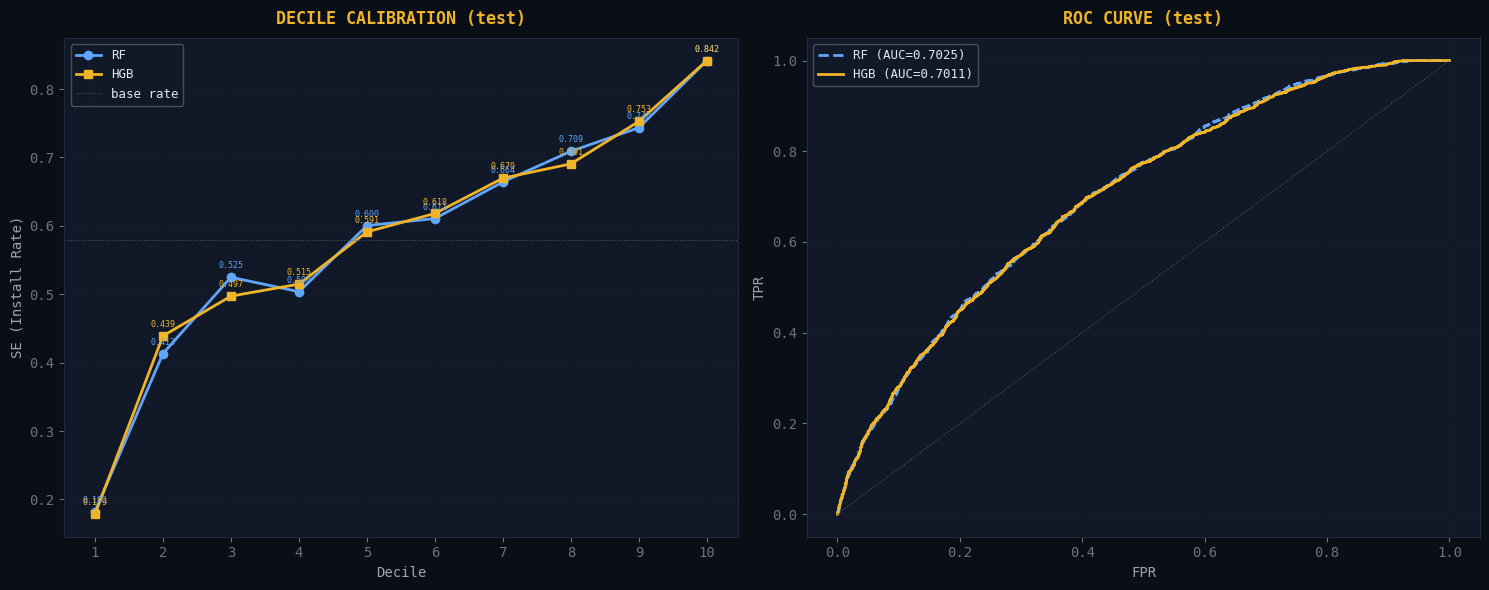

In [9]:
p_rf  = best_rf.predict(X_test)
p_hgb = best_hgb.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Decile curves ──
ax = axes[0]
for preds, label, color, marker in [
    (p_rf,  "RF",  BLUE,  "o"),
    (p_hgb, "HGB", AMBER, "s"),
]:
    edf = pd.DataFrame({"y": y_test.values, "p": preds})
    edf["d"] = pd.qcut(edf["p"], q=10, labels=False, duplicates="drop") + 1
    tbl = edf.groupby("d").agg(n=("y","count"), inst=("y","sum"))
    tbl["se"] = tbl["inst"] / tbl["n"]
    d = list(range(1, len(tbl) + 1))
    ax.plot(d, tbl["se"].values, f"{marker}-", color=color, linewidth=2, markersize=6, label=label)
    for j, se in enumerate(tbl["se"].values):
        ax.annotate(f"{se:.3f}", (j+1, se), fontsize=6, ha="center", va="bottom",
                    xytext=(0, 5), textcoords="offset points", color=color)

ax.axhline(y_test.mean(), color=GRAY, linestyle=":", linewidth=0.8, label="base rate")
ax.set_xlabel("Decile")
ax.set_ylabel("SE (Install Rate)")
ax.set_title("DECILE CALIBRATION (test)", fontsize=12, fontweight="bold", color=AMBER, pad=10)
ax.set_xticks(range(1, 11))
ax.legend(fontsize=9, framealpha=0.3)
ax.grid(alpha=0.2)

# ── ROC ──
ax = axes[1]
for preds, label, color, ls in [
    (p_rf,  "RF",  BLUE,  "--"),
    (p_hgb, "HGB", AMBER, "-"),
]:
    fpr, tpr, _ = roc_curve(y_test, preds)
    a = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2, linestyle=ls, label=f"{label} (AUC={a:.4f})")

ax.plot([0, 1], [0, 1], ":", color=GRAY, linewidth=0.8)
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.set_title("ROC CURVE (test)", fontsize=12, fontweight="bold", color=AMBER, pad=10)
ax.legend(fontsize=9, framealpha=0.3)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### 8b · Feature Importance (best RF)

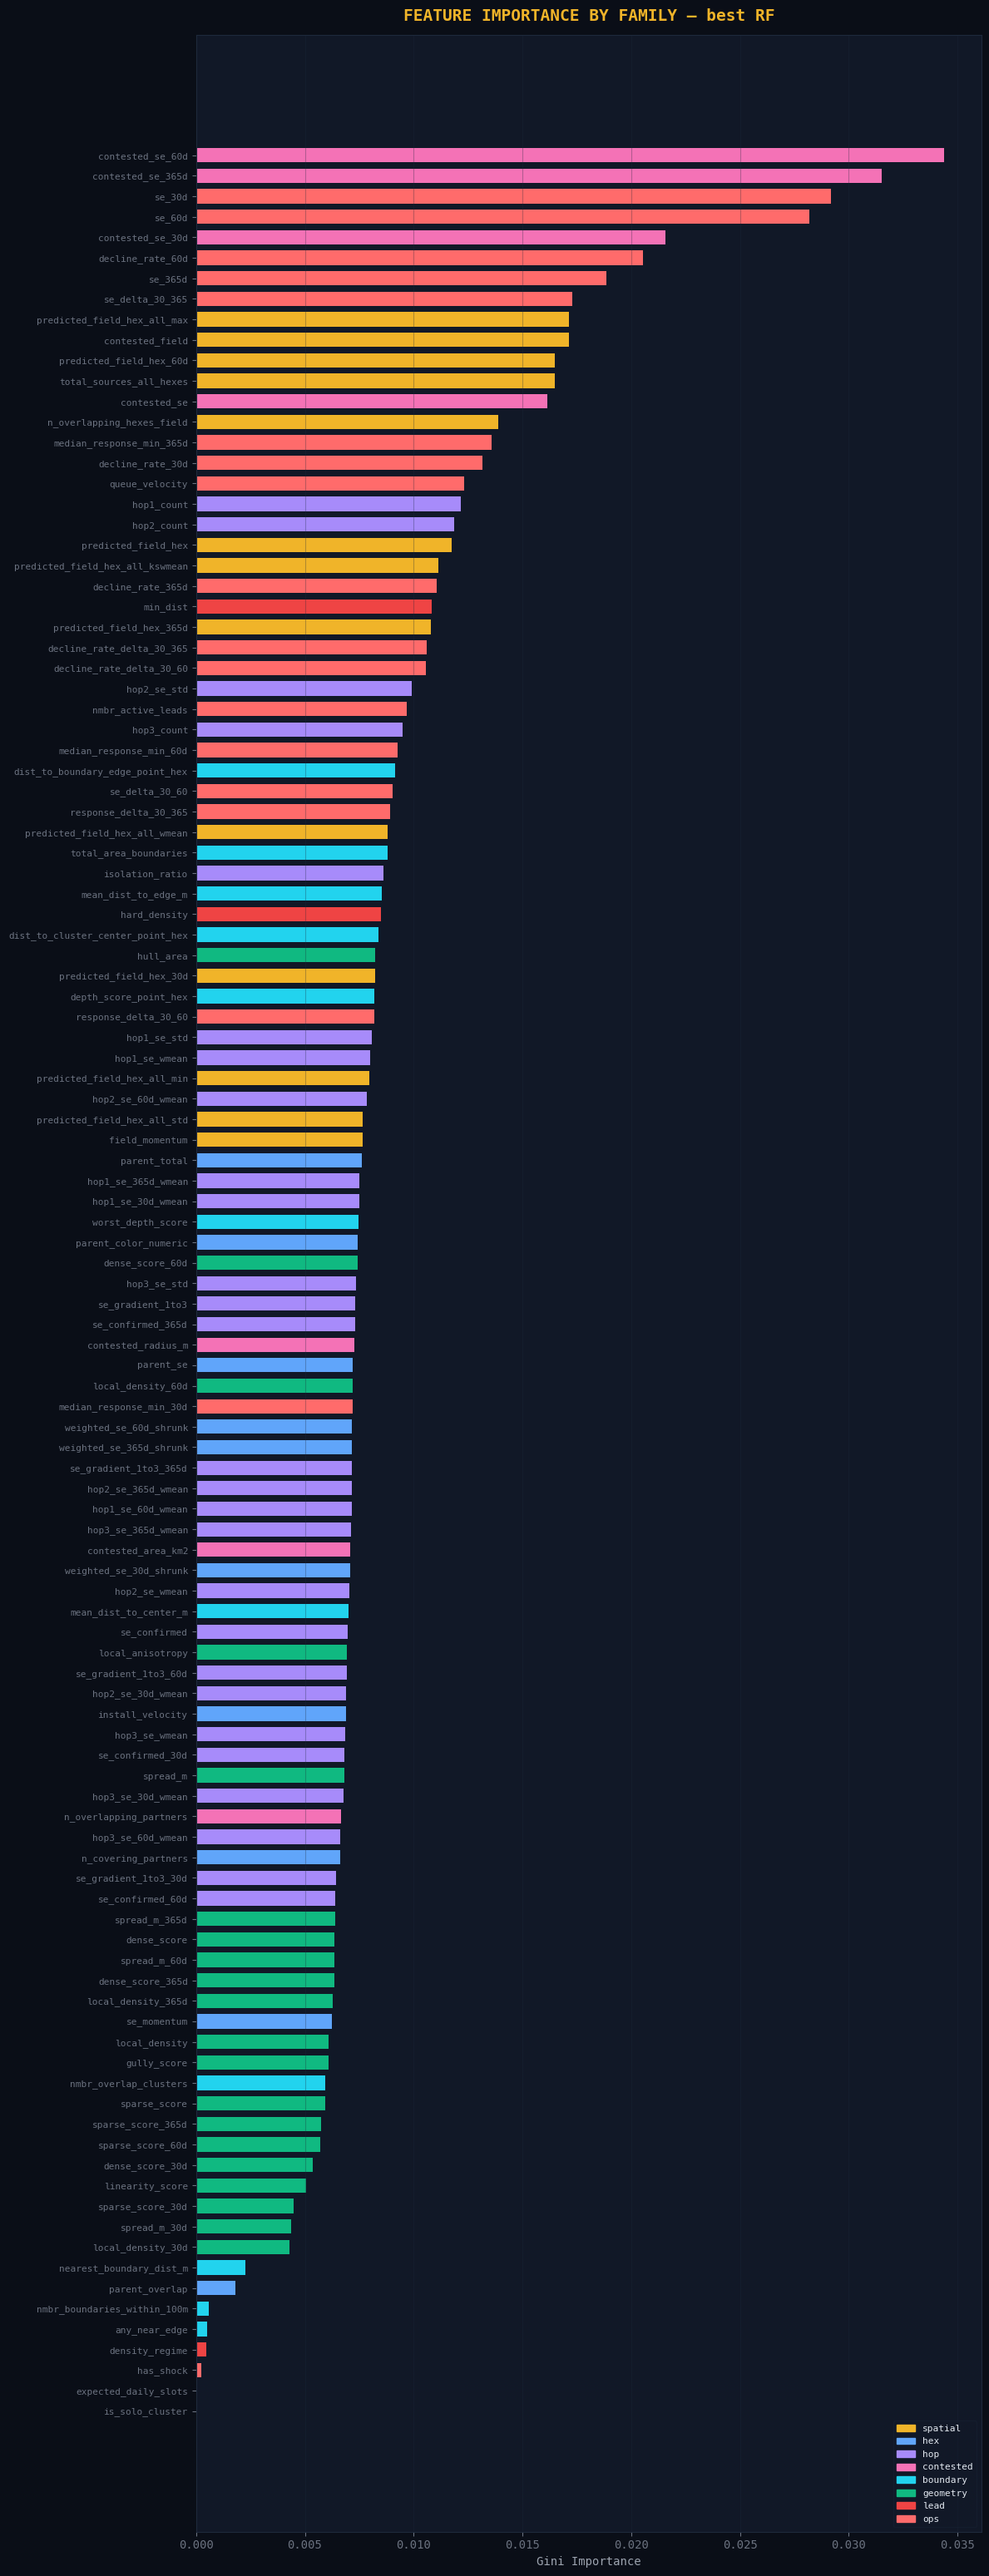

In [10]:
# ── Family color map ──
_families = {
    "spatial": [
        "predicted_field_hex", "predicted_field_hex_all_wmean", "predicted_field_hex_all_kswmean",
        "predicted_field_hex_all_min", "predicted_field_hex_all_max", "predicted_field_hex_all_std",
        "n_overlapping_hexes_field", "total_sources_all_hexes", "contested_field",
        "predicted_field_hex_30d", "predicted_field_hex_60d", "predicted_field_hex_365d",
        "field_momentum",
    ],
    "hex": [
        "parent_se", "parent_total", "parent_color_numeric", "n_covering_partners",
        "parent_overlap", "install_velocity",
        "weighted_se_30d_shrunk", "weighted_se_60d_shrunk", "weighted_se_365d_shrunk",
        "se_momentum",
    ],
    "hop": [
        "hop1_se_wmean", "hop2_se_wmean", "hop3_se_wmean",
        "hop1_se_std", "hop2_se_std", "hop3_se_std",
        "hop1_count", "hop2_count", "hop3_count",
        "se_gradient_1to3", "se_confirmed", "isolation_ratio",
        "hop1_se_30d_wmean", "hop2_se_30d_wmean", "hop3_se_30d_wmean",
        "hop1_se_60d_wmean", "hop2_se_60d_wmean", "hop3_se_60d_wmean",
        "hop1_se_365d_wmean", "hop2_se_365d_wmean", "hop3_se_365d_wmean",
        "se_gradient_1to3_30d", "se_gradient_1to3_60d", "se_gradient_1to3_365d",
        "se_confirmed_30d", "se_confirmed_60d", "se_confirmed_365d",
    ],
    "contested": [
        "contested_area_km2", "contested_radius_m", "contested_se",
        "contested_se_30d", "contested_se_60d", "contested_se_365d",
        "n_overlapping_partners",
    ],
    "boundary": [
        "dist_to_boundary_edge_point_hex", "dist_to_cluster_center_point_hex",
        "depth_score_point_hex", "mean_dist_to_edge_m", "mean_dist_to_center_m",
        "total_area_boundaries", "nmbr_overlap_clusters",
        "nearest_boundary_dist_m", "nmbr_boundaries_within_100m",
        "worst_depth_score", "any_near_edge", "is_solo_cluster",
    ],
    "geometry": [
        "local_anisotropy", "local_density", "hull_area", "linearity_score", "spread_m",
        "dense_score", "gully_score", "sparse_score",
        "local_density_30d", "local_density_60d", "local_density_365d",
        "dense_score_30d", "dense_score_60d", "dense_score_365d",
        "sparse_score_30d", "sparse_score_60d", "sparse_score_365d",
        "spread_m_30d", "spread_m_60d", "spread_m_365d",
    ],
    "lead": ["hard_density", "density_regime", "min_dist"],
    "ops": _ops_feature_cols,
}
family_map = {}
for fam, feats in _families.items():
    for f in feats:
        family_map[f] = fam

fam_colors = {
    "spatial": AMBER, "hex": BLUE, "hop": PURPLE, "contested": PINK,
    "boundary": CYAN, "geometry": GREEN, "lead": RED, "ops": "#ff6b6b",
}

imp = pd.Series(best_rf.feature_importances_, index=available).sort_values(ascending=True)
colors = [fam_colors.get(family_map.get(f, ""), GRAY) for f in imp.index]

fig, ax = plt.subplots(figsize=(12, max(10, len(imp) * 0.28)))
ax.barh(range(len(imp)), imp.values, color=colors, height=0.7, edgecolor="none")
ax.set_yticks(range(len(imp)))
ax.set_yticklabels(imp.index, fontsize=8)
ax.set_xlabel("Gini Importance")
ax.set_title("FEATURE IMPORTANCE BY FAMILY — best RF", fontsize=14, fontweight="bold", color=AMBER, pad=12)
ax.grid(axis="x", alpha=0.3)

patches = [mpatches.Patch(color=c, label=k) for k, c in fam_colors.items()]
ax.legend(handles=patches, loc="lower right", fontsize=8, framealpha=0.3, edgecolor="#1e293b")
plt.tight_layout()
plt.show()

### 8c · Single Tree (depth=4 excerpt)

In [11]:
single_tree = best_rf.estimators_[0]
print(export_text(single_tree, feature_names=available, max_depth=4))

|--- decline_rate_60d <= 0.76
|   |--- dense_score_30d <= 0.08
|   |   |--- predicted_field_hex_all_max <= 0.03
|   |   |   |--- contested_se_365d <= 0.60
|   |   |   |   |--- n_covering_partners <= 29.50
|   |   |   |   |   |--- truncated branch of depth 15
|   |   |   |   |--- n_covering_partners >  29.50
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- contested_se_365d >  0.60
|   |   |   |   |--- hop2_count <= 203.00
|   |   |   |   |   |--- truncated branch of depth 8
|   |   |   |   |--- hop2_count >  203.00
|   |   |   |   |   |--- value: [0.27]
|   |   |--- predicted_field_hex_all_max >  0.03
|   |   |   |--- se_confirmed <= 0.02
|   |   |   |   |--- contested_se_365d <= 0.56
|   |   |   |   |   |--- truncated branch of depth 9
|   |   |   |   |--- contested_se_365d >  0.56
|   |   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- se_confirmed >  0.02
|   |   |   |   |--- se_60d <= 0.44
|   |   |   |   |   |--- truncated branch of depth 11
|   

## 9 · Correlation & Collinearity Analysis

In [12]:
# ── Feature vs target correlation ──
feat_df = df[available + [TARGET]].copy()
corr_target = feat_df.corr()[TARGET].drop(TARGET).sort_values(ascending=False)

print("Correlation with installed_decision:\n")
for feat, val in corr_target.items():
    bar = "█" * int(abs(val) * 200)
    sign = "+" if val >= 0 else "-"
    print(f"  {sign}{abs(val):.4f}  {feat:40s}  {bar}")

# ── High collinearity pairs ──
corr_matrix = df[available].corr()
high_corr = []
for i in range(len(available)):
    for j in range(i + 1, len(available)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            high_corr.append((available[i], available[j], round(r, 3)))

high_corr.sort(key=lambda x: -abs(x[2]))
print(f"\nHighly correlated pairs (|r| > 0.7): {len(high_corr)}\n")
for a, b, r in high_corr[:30]:
    print(f"  {r:+.3f}  {a}  <->  {b}")

Correlation with installed_decision:

  +0.1967  se_60d                                    ███████████████████████████████████████
  +0.1948  se_30d                                    ██████████████████████████████████████
  +0.1856  contested_se_60d                          █████████████████████████████████████
  +0.1698  contested_se_365d                         █████████████████████████████████
  +0.1536  predicted_field_hex_60d                   ██████████████████████████████
  +0.1473  se_365d                                   █████████████████████████████
  +0.1454  contested_se_30d                          █████████████████████████████
  +0.1450  predicted_field_hex_30d                   ████████████████████████████
  +0.1399  se_delta_30_365                           ███████████████████████████
  +0.1381  predicted_field_hex_365d                  ███████████████████████████
  +0.1381  predicted_field_hex                       ███████████████████████████
  +0.1381  predicted_fie

ValueError: cannot convert float NaN to integer

### Importance vs Correlation scatter

In [ ]:
imp_desc = pd.Series(best_rf.feature_importances_, index=available)

fig, ax = plt.subplots(figsize=(10, 8))
for feat in imp_desc.index:
    c = fam_colors.get(family_map.get(feat, ""), GRAY)
    ax.scatter(corr_target.get(feat, 0), imp_desc[feat],
               c=c, s=60, alpha=0.85, edgecolor="white", linewidth=0.3, zorder=3)

for feat in imp_desc.nlargest(10).index:
    if feat in corr_target.index:
        ax.annotate(feat, (corr_target[feat], imp_desc[feat]),
                    fontsize=7, color="#9ca3af", ha="left",
                    xytext=(5, 5), textcoords="offset points")

ax.axvline(0, color=GRAY, linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Pearson r with target")
ax.set_ylabel("RF Importance")
ax.set_title("IMPORTANCE vs CORRELATION", fontsize=11, fontweight="bold", color=AMBER, pad=12)
ax.grid(alpha=0.2)

patches = [mpatches.Patch(color=c, label=k) for k, c in fam_colors.items()]
ax.legend(handles=patches, loc="upper left", fontsize=8, framealpha=0.3, edgecolor="#1e293b")
plt.tight_layout()
plt.show()

## 10 · Comparison with Existing Scores

In [13]:
# Score the full dataset with both best models
df["rf_score"]  = best_rf.predict(df[available].fillna(FILL_VALUE))
df["hgb_score"] = best_hgb.predict(df[available].fillna(FILL_VALUE))

def score_summary(score_col):
    """Compute AUC, decile gap, mono for a score column on full labelled data."""
    mask = df[TARGET].notna()
    sub = df[mask]
    auc_val = roc_auc_score(sub[TARGET], sub[score_col])
    d = pd.qcut(sub[score_col], q=10, labels=False, duplicates="drop") + 1
    tbl = sub.groupby(d).agg(n=(TARGET, "count"), inst=(TARGET, "sum"))
    tbl["se"] = tbl["inst"] / tbl["n"]
    gap = (tbl["se"].iloc[-1] - tbl["se"].iloc[0]) * 100
    mono = bool((tbl["se"].diff().dropna() >= 0).all())
    comp = auc_val * 100 + gap
    return auc_val, gap, mono, comp

print(f"{'Score':25s}  {'AUC':>7s}  {'gap_pp':>7s}  {'composite':>10s}  {'mono':>5s}")
print("-" * 62)
for col in ["rf_score", "hgb_score", "composite_score", "spatial_shrunk"]:
    if col in df.columns:
        a, g, m, c = score_summary(col)
        print(f"{col:25s}  {a:7.4f}  {g:7.2f}  {c:10.2f}  {str(m):>5s}")

Score                          AUC   gap_pp   composite   mono
--------------------------------------------------------------
rf_score                    0.8420    89.50      173.70   True
hgb_score                   0.8118    85.81      166.99   True
spatial_shrunk              0.5961    21.72       81.33  False
